Image Degradation for COCO val2017
Simulates adverse weather conditions: fog, rain, snow, blur, noise

In [4]:
# Image Degradation for COCO val2017
# Simulates adverse weather conditions: fog, rain, snow, blur, noise

import cv2
import numpy as np
import os
import glob
from tqdm import tqdm
import json
import matplotlib.pyplot as plt

def add_fog(image, intensity=0.5):
    """Add fog effect to image.
    
    Args:
        image: BGR image
        intensity: Fog intensity (0.0 to 1.0)
    """
    h, w = image.shape[:2]
    
    # Create fog layer
    fog = np.ones_like(image, dtype=np.float32) * 255
    
    # Create depth-like gradient (fog is denser at top/distance)
    depth_map = np.linspace(0.3, 1.0, h).reshape(-1, 1)
    depth_map = np.tile(depth_map, (1, w))
    depth_map = np.stack([depth_map] * 3, axis=2)
    
    # Add some randomness
    noise = np.random.normal(1.0, 0.1, depth_map.shape).astype(np.float32)
    depth_map = depth_map * noise
    depth_map = np.clip(depth_map, 0.3, 1.0)
    
    # Blend with fog
    alpha = intensity * depth_map
    result = (1 - alpha) * image.astype(np.float32) + alpha * fog
    
    return np.clip(result, 0, 255).astype(np.uint8)


def add_rain(image, intensity=0.5):
    """Add rain streaks to image.
    
    Args:
        image: BGR image
        intensity: Rain intensity (0.0 to 1.0)
    """
    h, w = image.shape[:2]
    result = image.copy()
    
    # Number of rain drops based on intensity
    num_drops = int(intensity * 2000)
    
    # Create rain streaks
    rain_layer = np.zeros_like(image, dtype=np.uint8)
    
    for _ in range(num_drops):
        x = np.random.randint(0, w)
        y = np.random.randint(0, h)
        length = np.random.randint(10, 30)
        thickness = np.random.randint(1, 2)
        
        # Rain falls at slight angle
        angle = np.random.uniform(-0.1, 0.1)
        x2 = int(x + length * angle)
        y2 = min(y + length, h - 1)
        
        # Gray-white color for rain
        color = (200, 200, 200)
        cv2.line(rain_layer, (x, y), (x2, y2), color, thickness)
    
    # Blur rain slightly
    rain_layer = cv2.GaussianBlur(rain_layer, (3, 3), 0)
    
    # Blend rain with image
    alpha = 0.3 + intensity * 0.4
    result = cv2.addWeighted(result, 1.0, rain_layer, alpha, 0)
    
    # Slightly darken and desaturate for rainy atmosphere
    result = cv2.convertScaleAbs(result, alpha=0.9, beta=-10)
    
    return result


def add_snow(image, intensity=0.5):
    """Add snow effect to image.
    
    Args:
        image: BGR image
        intensity: Snow intensity (0.0 to 1.0)
    """
    h, w = image.shape[:2]
    result = image.copy()
    
    # Number of snowflakes
    num_flakes = int(intensity * 3000)
    
    # Create snow layer
    snow_layer = np.zeros_like(image, dtype=np.uint8)
    
    for _ in range(num_flakes):
        x = np.random.randint(0, w)
        y = np.random.randint(0, h)
        radius = np.random.randint(1, 4)
        
        # White snowflakes
        cv2.circle(snow_layer, (x, y), radius, (255, 255, 255), -1)
    
    # Blur snow for soft effect
    snow_layer = cv2.GaussianBlur(snow_layer, (5, 5), 0)
    
    # Blend snow with image
    alpha = 0.3 + intensity * 0.5
    result = cv2.addWeighted(result, 1.0, snow_layer, alpha, 0)
    
    # Add slight brightness for snowy atmosphere
    result = cv2.convertScaleAbs(result, alpha=1.0, beta=int(intensity * 20))
    
    return result


def add_gaussian_noise(image, intensity=0.5):
    """Add Gaussian noise to image.
    
    Args:
        image: BGR image
        intensity: Noise intensity (0.0 to 1.0)
    """
    sigma = intensity * 50
    noise = np.random.normal(0, sigma, image.shape).astype(np.float32)
    result = image.astype(np.float32) + noise
    return np.clip(result, 0, 255).astype(np.uint8)


def add_motion_blur(image, intensity=0.5):
    """Add motion blur to image.
    
    Args:
        image: BGR image
        intensity: Blur intensity (0.0 to 1.0)
    """
    kernel_size = int(5 + intensity * 20)
    if kernel_size % 2 == 0:
        kernel_size += 1
    
    # Create motion blur kernel (horizontal)
    kernel = np.zeros((kernel_size, kernel_size))
    kernel[kernel_size // 2, :] = 1.0 / kernel_size
    
    return cv2.filter2D(image, -1, kernel)


def add_low_light(image, intensity=0.5):
    """Simulate low light conditions.
    
    Args:
        image: BGR image
        intensity: Darkness intensity (0.0 to 1.0)
    """
    # Reduce brightness
    gamma = 1.0 + intensity * 1.5
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype(np.uint8)
    result = cv2.LUT(image, table)
    
    # Add noise (common in low light)
    noise = np.random.normal(0, intensity * 15, result.shape).astype(np.float32)
    result = result.astype(np.float32) + noise
    
    return np.clip(result, 0, 255).astype(np.uint8)


def add_haze(image, intensity=0.5):
    """Add haze/smog effect.
    
    Args:
        image: BGR image
        intensity: Haze intensity (0.0 to 1.0)
    """
    # Atmospheric light (slightly yellowish for smog)
    A = np.array([240, 235, 220], dtype=np.float32)
    
    # Transmission map
    t = 1.0 - intensity * 0.7
    
    # Apply haze model: I = J*t + A*(1-t)
    result = image.astype(np.float32) * t + A * (1 - t)
    
    return np.clip(result, 0, 255).astype(np.uint8)


def degrade_image(image, degradation_type='fog', intensity=0.5):
    """Apply specified degradation to image.
    
    Args:
        image: BGR image
        degradation_type: Type of degradation ('fog', 'rain', 'snow', 'noise', 'blur', 'lowlight', 'haze')
        intensity: Degradation intensity (0.0 to 1.0)
    
    Returns:
        Degraded image
    """
    degradation_functions = {
        'fog': add_fog,
        'rain': add_rain,
        'snow': add_snow,
        'noise': add_gaussian_noise,
        'blur': add_motion_blur,
        'lowlight': add_low_light,
        'haze': add_haze
    }
    
    if degradation_type not in degradation_functions:
        raise ValueError(f"Unknown degradation type: {degradation_type}. Available: {list(degradation_functions.keys())}")
    
    return degradation_functions[degradation_type](image, intensity)


def process_coco_degradation(input_dir, output_dir, degradation_type='fog', intensity=0.5, max_images=None):
    """
    Apply degradation to COCO val2017 images and save to output directory.
    
    Args:
        input_dir: Path to COCO val2017 images
        output_dir: Path to save degraded images
        degradation_type: Type of degradation to apply
        intensity: Degradation intensity (0.0 to 1.0)
        max_images: Maximum number of images to process (None for all)
    
    Returns:
        Number of images processed
    """
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Get all images
    image_files = glob.glob(os.path.join(input_dir, "*.jpg"))
    
    if max_images:
        image_files = image_files[:max_images]
    
    print(f"\n{'='*60}")
    print(f"COCO Image Degradation")
    print(f"{'='*60}")
    print(f"Input directory: {input_dir}")
    print(f"Output directory: {output_dir}")
    print(f"Degradation type: {degradation_type}")
    print(f"Intensity: {intensity}")
    print(f"Images to process: {len(image_files)}")
    print(f"{'='*60}\n")
    
    processed = 0
    
    for img_path in tqdm(image_files, desc=f"Applying {degradation_type}"):
        try:
            # Read image
            image = cv2.imread(img_path)
            if image is None:
                continue
            
            # Apply degradation
            degraded = degrade_image(image, degradation_type, intensity)
            
            # Save to output directory
            filename = os.path.basename(img_path)
            output_path = os.path.join(output_dir, filename)
            cv2.imwrite(output_path, degraded)
            
            processed += 1
            
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue
    
    print(f"\n{'='*60}")
    print(f"Degradation Complete!")
    print(f"Processed: {processed} images")
    print(f"Output saved to: {output_dir}")
    print(f"{'='*60}")
    
    return processed


def process_all_degradations(input_dir, base_output_dir, intensity=0.5, max_images=None):
    """
    Apply all degradation types and save to separate folders.
    
    Args:
        input_dir: Path to COCO val2017 images
        base_output_dir: Base path for output (subfolders will be created)
        intensity: Degradation intensity
        max_images: Maximum images per degradation type
    """
    degradation_types = ['fog', 'rain', 'snow', 'noise', 'blur', 'lowlight', 'haze']
    
    results = {}
    
    for deg_type in degradation_types:
        output_dir = os.path.join(base_output_dir, deg_type)
        count = process_coco_degradation(input_dir, output_dir, deg_type, intensity, max_images)
        results[deg_type] = count
    
    print(f"\n{'='*60}")
    print("All Degradations Complete!")
    print(f"{'='*60}")
    for deg_type, count in results.items():
        print(f"  {deg_type:10s}: {count} images")
    
    return results


# Visualization function
def visualize_degradations(image_path, intensity=0.5):
    """Show all degradation types on a single image."""
    image = cv2.imread(image_path)
    if image is None:
        print(f"Could not read image: {image_path}")
        return
    
    degradation_types = ['fog', 'rain', 'snow', 'noise', 'blur', 'lowlight', 'haze']
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    
    # Original
    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")
    axes[0].axis('off')
    
    # Degraded versions
    for i, deg_type in enumerate(degradation_types):
        degraded = degrade_image(image, deg_type, intensity)
        axes[i + 1].imshow(cv2.cvtColor(degraded, cv2.COLOR_BGR2RGB))
        axes[i + 1].set_title(f"{deg_type.capitalize()} (intensity={intensity})")
        axes[i + 1].axis('off')
    
    plt.tight_layout()
    plt.show()


print("Image degradation functions loaded!")
print("\nAvailable degradation types:")
print("  - fog: Simulates foggy conditions")
print("  - rain: Adds rain streaks")
print("  - snow: Adds snowflakes")
print("  - noise: Adds Gaussian noise")
print("  - blur: Adds motion blur")
print("  - lowlight: Simulates low light conditions")
print("  - haze: Adds haze/smog effect")
print("\nUsage:")
print("  # Apply single degradation:")
print("  process_coco_degradation(")
print("      r'C:\\desktop 2\\project\\datasets\\COCO\\val2017',")
print("      r'C:\\desktop 2\\project\\datasets\\COCO\\val2017_degraded',")
print("      degradation_type='fog', intensity=0.5)")
print("\n  # Apply all degradations:")
print("  process_all_degradations(")
print("      r'C:\\desktop 2\\project\\datasets\\COCO\\val2017',")
print("      r'C:\\desktop 2\\project\\datasets\\COCO\\val2017_degraded')")

Image degradation functions loaded!

Available degradation types:
  - fog: Simulates foggy conditions
  - rain: Adds rain streaks
  - snow: Adds snowflakes
  - noise: Adds Gaussian noise
  - blur: Adds motion blur
  - lowlight: Simulates low light conditions
  - haze: Adds haze/smog effect

Usage:
  # Apply single degradation:
  process_coco_degradation(
      r'C:\desktop 2\project\datasets\COCO\val2017',
      r'C:\desktop 2\project\datasets\COCO\val2017_degraded',
      degradation_type='fog', intensity=0.5)

  # Apply all degradations:
  process_all_degradations(
      r'C:\desktop 2\project\datasets\COCO\val2017',
      r'C:\desktop 2\project\datasets\COCO\val2017_degraded')


haze 0.5,1,1.5 datasets creation

In [2]:
# Create COCO Haze Datasets with different intensities (0.5, 1.0, 1.5)
# Each dataset will be stored in a separate folder

import cv2
import numpy as np
import os
import glob
from tqdm import tqdm

def create_haze_dataset(input_dir, output_dir, intensity):
    """
    Apply haze degradation to all images and save to output directory.
    
    Args:
        input_dir: Path to source COCO images
        output_dir: Path to save hazed images
        intensity: Haze intensity value
    """
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Get all images
    image_files = sorted(glob.glob(os.path.join(input_dir, "*.jpg")))
    
    print(f"\n{'='*60}")
    print(f"Creating Haze Dataset - Intensity: {intensity}")
    print(f"{'='*60}")
    print(f"Input directory: {input_dir}")
    print(f"Output directory: {output_dir}")
    print(f"Images to process: {len(image_files)}")
    print(f"{'='*60}\n")
    
    processed = 0
    
    for img_path in tqdm(image_files, desc=f"Haze intensity {intensity}"):
        try:
            # Read image
            image = cv2.imread(img_path)
            if image is None:
                continue
            
            # Apply haze using the add_haze function
            hazed = add_haze(image, intensity)
            
            # Save to output directory
            filename = os.path.basename(img_path)
            output_path = os.path.join(output_dir, filename)
            cv2.imwrite(output_path, hazed)
            
            processed += 1
            
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue
    
    print(f"Completed: {processed} images saved to {output_dir}")
    return processed

# Paths
input_dir = r"C:\desktop 2\project\datasets\COCO\val2017"
base_output = r"C:\desktop 2\project\datasets\COCO"

# Define haze intensities and output folder names
haze_configs = [
    (0.5, "COCO_haze_0.5"),
    (1.0, "COCO_haze_1.0"),
    (1.5, "COCO_haze_1.5")
]

# Process each haze intensity
results = {}
for intensity, folder_name in haze_configs:
    output_dir = os.path.join(base_output, folder_name)
    count = create_haze_dataset(input_dir, output_dir, intensity)
    results[folder_name] = count

# Summary
print(f"\n{'='*60}")
print("All Haze Datasets Created!")
print(f"{'='*60}")
for folder, count in results.items():
    print(f"  {folder}: {count} images")
print(f"{'='*60}")


Creating Haze Dataset - Intensity: 0.5
Input directory: C:\desktop 2\project\datasets\COCO\val2017
Output directory: C:\desktop 2\project\datasets\COCO\COCO_haze_0.5
Images to process: 5000



Haze intensity 0.5: 100%|██████████| 5000/5000 [00:41<00:00, 121.89it/s]


Completed: 5000 images saved to C:\desktop 2\project\datasets\COCO\COCO_haze_0.5

Creating Haze Dataset - Intensity: 1.0
Input directory: C:\desktop 2\project\datasets\COCO\val2017
Output directory: C:\desktop 2\project\datasets\COCO\COCO_haze_1.0
Images to process: 5000



Haze intensity 1.0: 100%|██████████| 5000/5000 [00:38<00:00, 129.67it/s]


Completed: 5000 images saved to C:\desktop 2\project\datasets\COCO\COCO_haze_1.0

Creating Haze Dataset - Intensity: 1.5
Input directory: C:\desktop 2\project\datasets\COCO\val2017
Output directory: C:\desktop 2\project\datasets\COCO\COCO_haze_1.5
Images to process: 5000



Haze intensity 1.5: 100%|██████████| 5000/5000 [00:35<00:00, 140.61it/s]

Completed: 5000 images saved to C:\desktop 2\project\datasets\COCO\COCO_haze_1.5

All Haze Datasets Created!
  COCO_haze_0.5: 5000 images
  COCO_haze_1.0: 5000 images
  COCO_haze_1.5: 5000 images


splits into 7 segments of different adverse weather conditons


COCO Image Degradation - Distributed
Total images: 5000
Degradation types: 7
Images per type: ~714
Output directory: C:\desktop 2\project\datasets\COCO\val2017_degraded


Processing fog: images 1 to 715 (715 images)


Applying fog: 100%|██████████| 715/715 [00:25<00:00, 28.48it/s]



Processing rain: images 716 to 1430 (715 images)


Applying rain: 100%|██████████| 715/715 [00:08<00:00, 80.50it/s]



Processing snow: images 1431 to 2144 (714 images)


...


Processing lowlight: images 3573 to 4286 (714 images)


Applying lowlight: 100%|██████████| 714/714 [00:13<00:00, 51.70it/s]



Processing haze: images 4287 to 5000 (714 images)


Applying haze: 100%|██████████| 714/714 [00:05<00:00, 138.00it/s]



Degradation Complete!
  fog       : 715 images
  rain      : 715 images
  snow      : 714 images
  noise     : 714 images
  blur      : 714 images
  lowlight  : 714 images
  haze      : 714 images
  TOTAL     : 5000 images

Output saved to: C:\desktop 2\project\datasets\COCO\val2017_degraded

Visualization of all degradation types on sample image:


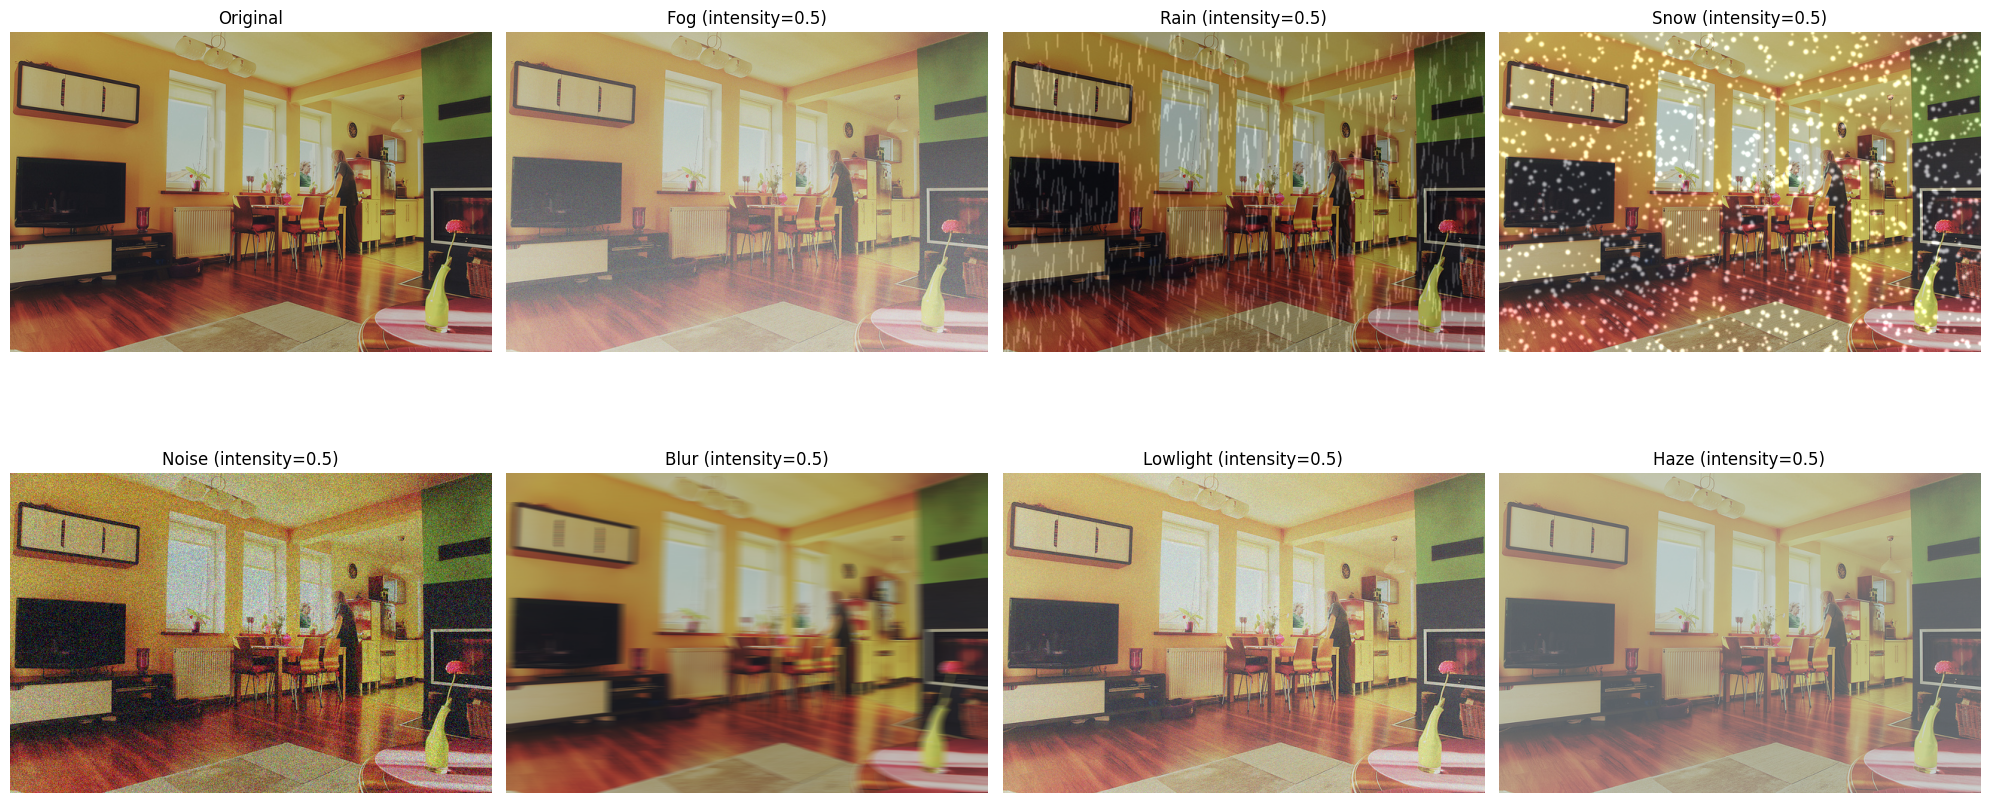

In [5]:
# Run image degradation on COCO val2017
# Divides 5000 images evenly among 7 degradation types (~714 images each)

input_dir = r"C:\desktop 2\project\datasets\COCO\val2017"
output_dir = r"C:\desktop 2\project\datasets\COCO\val2017_degraded"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Get all images
all_images = sorted(glob.glob(os.path.join(input_dir, "*.jpg")))
total_images = len(all_images)

# Degradation types
degradation_types = ['fog', 'rain', 'snow', 'noise', 'blur', 'lowlight', 'haze']
num_types = len(degradation_types)

# Calculate images per type
images_per_type = total_images // num_types
remainder = total_images % num_types

print(f"\n{'='*60}")
print(f"COCO Image Degradation - Distributed")
print(f"{'='*60}")
print(f"Total images: {total_images}")
print(f"Degradation types: {num_types}")
print(f"Images per type: ~{images_per_type}")
print(f"Output directory: {output_dir}")
print(f"{'='*60}\n")

# Process each degradation type with its portion of images
start_idx = 0
results = {}

for i, deg_type in enumerate(degradation_types):
    # Distribute remainder among first few types
    count = images_per_type + (1 if i < remainder else 0)
    end_idx = start_idx + count
    
    # Get image subset for this degradation type
    image_subset = all_images[start_idx:end_idx]
    
    print(f"\nProcessing {deg_type}: images {start_idx+1} to {end_idx} ({len(image_subset)} images)")
    
    processed = 0
    for img_path in tqdm(image_subset, desc=f"Applying {deg_type}"):
        try:
            image = cv2.imread(img_path)
            if image is None:
                continue
            
            # Apply degradation
            degraded = degrade_image(image, deg_type, intensity=0.5)
            
            # Save to output directory (same filename)
            filename = os.path.basename(img_path)
            output_path = os.path.join(output_dir, filename)
            cv2.imwrite(output_path, degraded)
            
            processed += 1
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue
    
    results[deg_type] = processed
    start_idx = end_idx

# Summary
print(f"\n{'='*60}")
print("Degradation Complete!")
print(f"{'='*60}")
for deg_type, count in results.items():
    print(f"  {deg_type:10s}: {count} images")
print(f"  {'TOTAL':10s}: {sum(results.values())} images")
print(f"\nOutput saved to: {output_dir}")

# Optional: Preview degradation on a sample image
sample_images = glob.glob(os.path.join(input_dir, "*.jpg"))[:1]
if sample_images:
    print("\nVisualization of all degradation types on sample image:")
    visualize_degradations(sample_images[0], intensity=0.5)

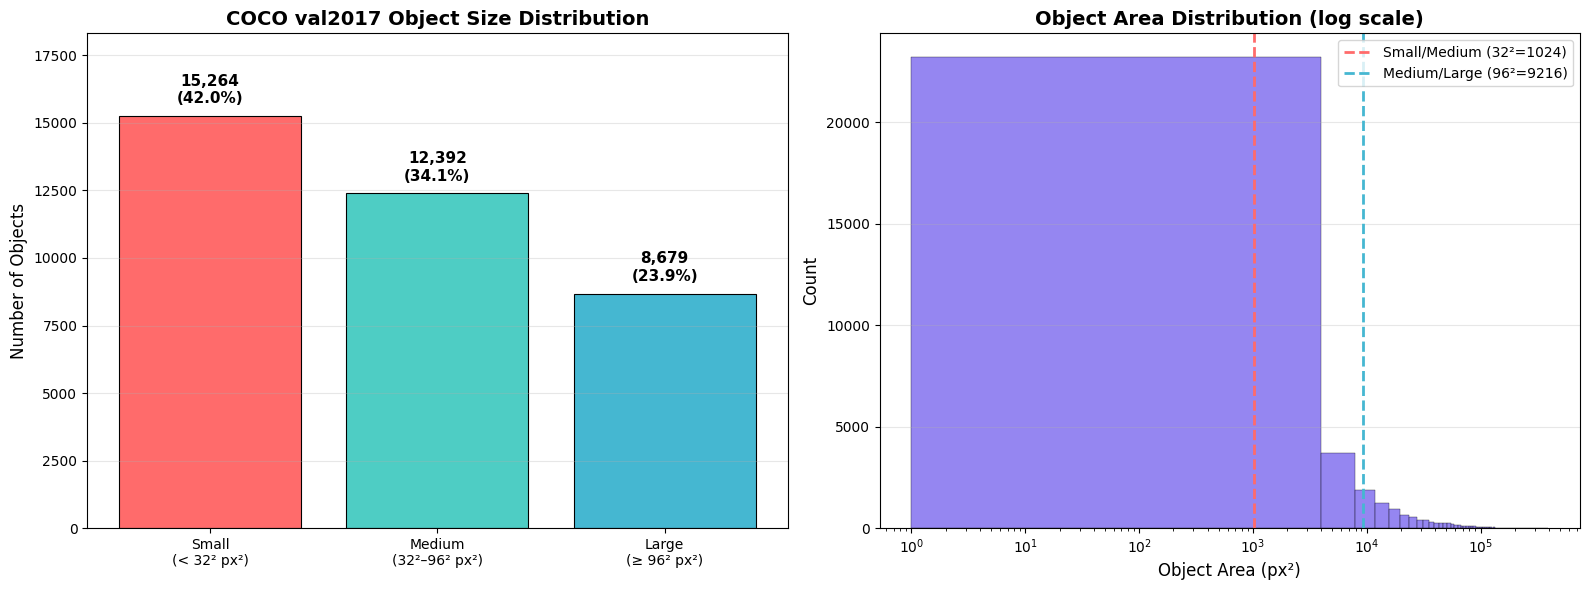


COCO val2017 Object Size Summary
  Total objects (non-crowd): 36,335
  Small  (area < 1024 px²):  15,264 (42.0%)
  Medium (1024 ≤ area < 9216): 12,392 (34.1%)
  Large  (area ≥ 9216 px²):   8,679 (23.9%)


In [7]:
# =============================================================================
# COCO val2017 Object Size Distribution & Size-Stratified Results
# =============================================================================

# --- 1. Load size distribution from COCO annotations ---
ann_path = r"C:\desktop 2\project\datasets\COCO\annotations\instances_val2017.json"

with open(ann_path, 'r') as f:
    coco_data = json.load(f)

# Count objects by size (excluding crowd annotations)
size_counts = {'Small\n(< 32² px²)': 0, 'Medium\n(32²–96² px²)': 0, 'Large\n(≥ 96² px²)': 0}
all_areas = []

for ann in coco_data['annotations']:
    if ann.get('iscrowd', 0):
        continue
    area = ann['area']
    all_areas.append(area)
    if area < 1024:
        size_counts['Small\n(< 32² px²)'] += 1
    elif area < 9216:
        size_counts['Medium\n(32²–96² px²)'] += 1
    else:
        size_counts['Large\n(≥ 96² px²)'] += 1

total = sum(size_counts.values())

# --- 2. Plot size distribution ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of object counts by size
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = axes[0].bar(size_counts.keys(), size_counts.values(), color=colors, edgecolor='black', linewidth=0.8)

# Add count + percentage labels on bars
for bar, count in zip(bars, size_counts.values()):
    pct = count / total * 100
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + total*0.01,
                 f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=11)

axes[0].set_ylabel('Number of Objects', fontsize=12)
axes[0].set_title('COCO val2017 Object Size Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, max(size_counts.values()) * 1.2)
axes[0].grid(axis='y', alpha=0.3)

# Area histogram (log scale)
axes[1].hist(all_areas, bins=100, color='#7B68EE', edgecolor='black', linewidth=0.3, alpha=0.8)
axes[1].axvline(x=1024, color='#FF6B6B', linestyle='--', linewidth=2, label=f'Small/Medium (32²={1024})')
axes[1].axvline(x=9216, color='#45B7D1', linestyle='--', linewidth=2, label=f'Medium/Large (96²={9216})')
axes[1].set_xlabel('Object Area (px²)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Object Area Distribution (log scale)', fontsize=14, fontweight='bold')
axes[1].set_xscale('log')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# --- 3. Print summary ---
print(f"\n{'='*60}")
print(f"COCO val2017 Object Size Summary")
print(f"{'='*60}")
print(f"  Total objects (non-crowd): {total:,}")
print(f"  Small  (area < 1024 px²):  {size_counts['Small' + chr(10) + '(< 32² px²)']:>6,} ({size_counts['Small' + chr(10) + '(< 32² px²)']/total*100:.1f}%)")
print(f"  Medium (1024 ≤ area < 9216): {size_counts['Medium' + chr(10) + '(32²–96² px²)']:>6,} ({size_counts['Medium' + chr(10) + '(32²–96² px²)']/total*100:.1f}%)")
print(f"  Large  (area ≥ 9216 px²):  {size_counts['Large' + chr(10) + '(≥ 96² px²)']:>6,} ({size_counts['Large' + chr(10) + '(≥ 96² px²)']/total*100:.1f}%)")
print(f"{'='*60}")
